# PoC Compare — xray_cond / finetuned / baseline

Visualizes the three-way comparison output from `09_poc_compare_samples.sh`:

| Section | Contents |
|---|---|
| 1. Config | Set `COMPARE_DIR` |
| 2. Load | Pocket PDB, reference ligand, generated SDF per condition |
| 3. NGLView | 3D molecular viewer: pocket surface + molecules |
| 4. Density | CCP4 density crop overlaid with generated molecules (Plotly) |
| 5. 2D grid | RDKit depictions per condition |
| 6. Metrics | Per-molecule metrics from `eval_results.pt` |

In [59]:
import sys, os, re, math, tempfile
from pathlib import Path
from io import BytesIO
from glob import glob

import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import torch
import gemmi

from rdkit import Chem, RDLogger
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import nglview as nv

RDLogger.DisableLog('rdApp.*')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})
print('Imports OK')

Imports OK


## 1. Config

In [60]:
# COMPARE_DIR = Path('../voxbind/exps/poc_xray/compare_test')
COMPARE_DIR = Path('../voxbind/exps/poc_xray/compare_20/pocket_0001')
CCP4_DIR    = Path('../voxbind/dataset/data/ccp4')

# Conditions to show (those present in COMPARE_DIR will be loaded)
CONDITIONS  = ['baseline', 'finetuned', 'xray_cond']

# Plotly colour per condition
COND_COLOR = {
    'baseline':  'cornflowerblue',
    'finetuned': 'gold',
    'xray_cond': 'tomato',
}

VOXEL_RES = 0.25
GRID_SIZE = 64

ELEM_COLOR = {'C': 'gray', 'N': 'cornflowerblue', 'O': 'tomato',
              'S': 'gold', 'F': 'limegreen', 'Cl': 'lime', 'P': 'orange'}
ELEM_SIZE  = {'C': 3.5, 'N': 3.5, 'O': 3.2, 'S': 4.5,
              'F': 2.8, 'Cl': 4.0, 'P': 4.0}

## 2. Load data

In [61]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def parse_pocket_pdb(pdb_path):
    coords, elems = [], []
    for line in open(pdb_path):
        if not (line.startswith('ATOM') or line.startswith('HETATM')):
            continue
        try:
            x, y, z = float(line[30:38]), float(line[38:46]), float(line[46:54])
        except ValueError:
            continue
        elem = line[76:78].strip() if len(line) > 76 else ''
        if not elem:
            elem = re.sub(r'[^A-Za-z]', '', line[12:16]).strip()[:2].capitalize()
        if elem in ('H', 'D'):
            continue
        coords.append([x, y, z])
        elems.append(elem)
    return np.array(coords, dtype=float), elems


def mol_coords(mol):
    conf = mol.GetConformer()
    return np.array([conf.GetAtomPosition(i) for i in range(mol.GetNumAtoms())])


def mol_elems(mol):
    return [a.GetSymbol() for a in mol.GetAtoms()]


def load_sdf(path):
    if not path.exists():
        return []
    return [m for m in Chem.SDMolSupplier(str(path), removeHs=False, sanitize=True)
            if m is not None]


# ── Pocket PDB ────────────────────────────────────────────────────────────────
pdb_files = sorted(COMPARE_DIR.glob('*pocket10.pdb'))
assert pdb_files, f'No pocket10.pdb found in {COMPARE_DIR}'
pocket_pdb = pdb_files[0]
poc_coords, poc_elems = parse_pocket_pdb(pocket_pdb)

# ── Reference ligand ──────────────────────────────────────────────────────────
ref_sdfs = [f for f in COMPARE_DIR.glob('*.sdf')
            if 'pocket10' not in f.name and 'samples' not in f.name]
ref_mol = None
if ref_sdfs:
    ref_mol = next(iter(Chem.SDMolSupplier(str(ref_sdfs[0]), removeHs=True, sanitize=True)), None)

# ── Generated molecules per condition ─────────────────────────────────────────
gen_mols = {}
for cond in CONDITIONS:
    sdf = COMPARE_DIR / cond / 'samples.sdf'
    mols = load_sdf(sdf)
    if mols:
        gen_mols[cond] = mols

# ── Ligand centroid (from reference ligand or pocket mean) ────────────────────
if ref_mol is not None:
    centroid = mol_coords(ref_mol).mean(axis=0)
else:
    centroid = poc_coords.mean(axis=0)

# ── Extract PDB ID from pocket filename for CCP4 lookup ──────────────────────
# e.g. COMT_MOUSE_...__5p8y_A_rec_5p9s_7jk_lig_...  → ligand PDB is '5p9s'
lig_match = re.search(r'rec_([0-9a-z]{4})_', pocket_pdb.stem)
pdb_id = lig_match.group(1) if lig_match else None
ccp4_path = CCP4_DIR / f'{pdb_id}.map' if pdb_id else None

print(f'Pocket PDB   : {pocket_pdb.name}')
print(f'Pocket atoms : {len(poc_coords)}')
print(f'Ref ligand   : {ref_sdfs[0].name if ref_sdfs else "not found"}')
print(f'Centroid     : {centroid.round(2)}')
print(f'CCP4 map     : {ccp4_path}  exists={ccp4_path.exists() if ccp4_path else False}')
print()
for cond, mols in gen_mols.items():
    print(f'  {cond:<12}  {len(mols)} molecules')

Pocket PDB   : KDM4A_HUMAN_1_358_0__5anq_A_rec_4bis_8hq_lig_tt_min_0_pocket10.pdb
Pocket atoms : 360
Ref ligand   : KDM4A_HUMAN_1_358_0__5anq_A_rec_4bis_8hq_lig_tt_min_0.sdf
Centroid     : [ -4.    14.64 -17.22]
CCP4 map     : ../voxbind/dataset/data/ccp4/4bis.map  exists=True

  baseline      10 molecules
  finetuned     2 molecules
  xray_cond     10 molecules


In [62]:

# ── Reference SMILES recovery check ──────────────────────────────────────────
if ref_mol is None:
    print('No reference ligand loaded — skipping SMILES check.')
else:
    ref_smi = Chem.MolToSmiles(ref_mol)
    print(f'Reference SMILES : {ref_smi}')
    print()
    for cond in CONDITIONS:
        mols = gen_mols.get(cond, [])
        if not mols:
            print(f'  {cond:<12}  (no molecules)')
            continue
        gen_smiles = {Chem.MolToSmiles(m) for m in mols}
        hit = ref_smi in gen_smiles
        print(f'  {cond:<12}  {"HIT ✓" if hit else "miss"}  ({len(gen_smiles)} unique SMILES)')


Reference SMILES : O=C(O)c1ccnc2c(O)cccc12

  baseline      miss  (10 unique SMILES)
  finetuned     miss  (2 unique SMILES)
  xray_cond     miss  (10 unique SMILES)


## 3. NGLView — Pocket surface + generated molecules

Set `SHOW_COND` to the condition you want to visualize (`'xray_cond'`, `'finetuned'`, or `'baseline'`).  
Set `MOL_IDX` to select which generated molecule to show.

In [63]:
SHOW_COND = 'xray_cond'   # ← change condition here
MOL_IDX   = 0             # ← which generated molecule to show (0-indexed)

mols_to_show = gen_mols.get(SHOW_COND, [])
if not mols_to_show:
    raise RuntimeError(f'No molecules for condition "{SHOW_COND}"')
mol = mols_to_show[min(MOL_IDX, len(mols_to_show) - 1)]

# Write mol to temp SDF
gen_sdf_tmp = os.path.join(tempfile.gettempdir(), f'{SHOW_COND}_mol{MOL_IDX}.sdf')
with Chem.SDWriter(gen_sdf_tmp) as w:
    w.write(mol)

view = nv.NGLWidget(height='600px', width='800px')

# Pocket — translucent surface
view.add_component(str(pocket_pdb))
view.clear_representations(component=0)
view.add_representation('surface', component=0, opacity=0.25,
                        color='element', surfaceType='av')
view.add_representation('ball+stick', component=0, opacity=0.1, color='element')

# Reference ligand — ball+stick
n_comp = 1
if ref_mol is not None:
    ref_sdf_tmp = os.path.join(tempfile.gettempdir(), 'ref_ligand.sdf')
    with Chem.SDWriter(ref_sdf_tmp) as w:
        w.write(ref_mol)
    view.add_component(ref_sdf_tmp)
    view.clear_representations(component=n_comp)
    view.add_representation('ball+stick', component=n_comp,
                            colorScheme='element', multipleBond='symmetric')
    view.add_representation('surface', component=n_comp, opacity=0.15,
                            color='green', surfaceType='vws')
    n_comp += 1

# Generated molecule — ball+stick + surface
view.add_component(gen_sdf_tmp)
view.clear_representations(component=n_comp)
view.add_representation('ball+stick', component=n_comp,
                        colorScheme='element', multipleBond='symmetric')
view.add_representation('surface', component=n_comp, opacity=0.5,
                        color='red', surfaceType='vws')

view.center()
smi = Chem.MolToSmiles(mol)
print(f'Condition   : {SHOW_COND}')
print(f'Molecule    : {MOL_IDX}/{len(mols_to_show)-1}')
print(f'SMILES      : {smi}')
print(f'Heavy atoms : {mol.GetNumHeavyAtoms()}')
view

Condition   : xray_cond
Molecule    : 0/9
SMILES      : CC[C@H](C)N=CC(=O)O
Heavy atoms : 9


NGLWidget()

In [64]:
# ── All conditions side by side ───────────────────────────────────────────────
# Shows the first molecule from each available condition simultaneously.

# Condition → nglview color (approximate)
NGL_COLOR = {'baseline': 'blue', 'finetuned': 'yellow', 'xray_cond': 'red'}

view2 = nv.NGLWidget(height='600px', width='900px')

# Pocket
view2.add_component(str(pocket_pdb))
view2.clear_representations(component=0)
view2.add_representation('surface', component=0, opacity=0.15,
                         color='element', surfaceType='av')

n_comp = 1

# Reference ligand
if ref_mol is not None:
    with Chem.SDWriter(ref_sdf_tmp) as w:
        w.write(ref_mol)
    view2.add_component(ref_sdf_tmp)
    view2.clear_representations(component=n_comp)
    view2.add_representation('ball+stick', component=n_comp,
                             colorScheme='element', multipleBond='symmetric')
    n_comp += 1

# One molecule per condition
for cond, mols in gen_mols.items():
    m = mols[0]
    tmp_path = os.path.join(tempfile.gettempdir(), f'{cond}_mol0_all.sdf')
    with Chem.SDWriter(tmp_path) as w:
        w.write(m)
    view2.add_component(tmp_path)
    view2.clear_representations(component=n_comp)
    view2.add_representation('ball+stick', component=n_comp, color=NGL_COLOR.get(cond, 'white'), multipleBond='symmetric')
    view2.add_representation('surface', component=n_comp, opacity=0.4, color=NGL_COLOR.get(cond, 'white'), surfaceType='vws')
    print(f'  {cond:<12} ({NGL_COLOR.get(cond)})  SMILES: {Chem.MolToSmiles(m)}')
    n_comp += 1

print('  reference    (element)  reference ligand')
view2.center()
view2

  baseline     (blue)  SMILES: C[C@H](N)c1cccc(C(=O)O)c1
  finetuned    (yellow)  SMILES: C
  xray_cond    (red)  SMILES: CC[C@H](C)N=CC(=O)O
  reference    (element)  reference ligand


NGLWidget()

In [65]:
# ── Per-condition NGL views ──────────────────────────────────────────────────
# One NGL widget per condition (plus a reference-only view).

from IPython.display import display

# Condition → nglview color (approximate)
NGL_COLOR = {'baseline': 'blue', 'finetuned': 'yellow', 'xray_cond': 'red'}


def make_ngl_view(label, mol, color='white'):
    view = nv.NGLWidget(height='600px', width='900px')

    # Pocket
    view.add_component(str(pocket_pdb))
    view.clear_representations(component=0)
    view.add_representation(
        'surface', component=0, opacity=0.15,
        color='element', surfaceType='av'
    )

    comp_idx = 1

    # Reference ligand (if available)
    if ref_mol is not None:
        ref_sdf_tmp = os.path.join(tempfile.gettempdir(), 'ref_ligand.sdf')
        with Chem.SDWriter(ref_sdf_tmp) as w:
            w.write(ref_mol)
        view.add_component(ref_sdf_tmp)
        view.clear_representations(component=comp_idx)
        view.add_representation(
            'ball+stick', component=comp_idx,
            colorScheme='element', multipleBond='symmetric'
        )
        comp_idx += 1

    # Optional generated molecule for this view
    if mol is not None:
        tmp_path = os.path.join(tempfile.gettempdir(), f'{label}_mol0_single.sdf')
        with Chem.SDWriter(tmp_path) as w:
            w.write(mol)
        view.add_component(tmp_path)
        view.clear_representations(component=comp_idx)
        view.add_representation(
            'ball+stick', component=comp_idx,
            color=color, multipleBond='symmetric'
        )
        view.add_representation(
            'surface', component=comp_idx,
            opacity=0.4, color=color, surfaceType='vws'
        )

    view.center()
    return view


# Build one widget per condition
views = {}

# Reference-only view
views['reference'] = make_ngl_view('reference', mol=None, color='white')
print('reference view: pocket + reference ligand (no generated molecule)')

# Per-condition views
for cond, mols in gen_mols.items():
    if not mols:
        continue
    m = mols[0]
    color = NGL_COLOR.get(cond, 'white')
    views[cond] = make_ngl_view(cond, m, color=color)
    print(f'  {cond:<12} ({color})  SMILES: {Chem.MolToSmiles(m)}')

# Display all widgets (one below another)
for name, v in views.items():
    print(f"\n=== {name} ===")
    display(v)

reference view: pocket + reference ligand (no generated molecule)
  baseline     (blue)  SMILES: C[C@H](N)c1cccc(C(=O)O)c1
  finetuned    (yellow)  SMILES: C
  xray_cond    (red)  SMILES: CC[C@H](C)N=CC(=O)O

=== reference ===


NGLWidget()


=== baseline ===


NGLWidget()


=== finetuned ===


NGLWidget()


=== xray_cond ===


NGLWidget()

## 4. X-ray Density + Generated Molecules (Plotly 3D)

Density crop aligned to the 64³ VoxBind grid. Generated molecules from each condition are shown as coloured spheres.

In [54]:
if ccp4_path is None or not ccp4_path.exists():
    print(f'WARNING: CCP4 map not found ({ccp4_path}). Skipping density section.')
    density_64 = None
else:
    m_ccp4 = gemmi.read_ccp4_map(str(ccp4_path))
    m_ccp4.setup(float('nan'))
    grid = m_ccp4.grid
    cell = grid.unit_cell

    arr = np.array(grid, dtype=np.float32)
    arr_norm = (arr - arr.mean()) / (arr.std() + 1e-10)
    nu, nv, nw = arr.shape

    orth_mat = np.array(cell.orth.mat.tolist())
    frac_T   = np.linalg.inv(orth_mat).T

    # Build 64³ query grid centred on ligand centroid
    G = GRID_SIZE
    grid_1d = (np.arange(G, dtype=np.float32) - (G - 1) / 2.0) * VOXEL_RES
    gi, gj, gk = np.meshgrid(grid_1d, grid_1d, grid_1d, indexing='ij')

    cart_pts = np.stack([
        (centroid[0] + gi).ravel(),
        (centroid[1] + gj).ravel(),
        (centroid[2] + gk).ravel(),
    ], axis=1)

    frac_pts = cart_pts @ frac_T
    ci_q = (frac_pts[:, 0] * nu) % nu
    cj_q = (frac_pts[:, 1] * nv) % nv
    ck_q = (frac_pts[:, 2] * nw) % nw

    density_64 = scipy.ndimage.map_coordinates(
        arr_norm, [ci_q, cj_q, ck_q], order=1, mode='wrap', prefilter=False
    ).reshape(G, G, G)

    d_sigma = density_64.std()
    print(f'CCP4 PDB     : {pdb_id}')
    print(f'Grid         : {nu}×{nv}×{nw}')
    print(f'64³ crop     : mean={density_64.mean():.4f}  sigma={d_sigma:.4f}')
    print(f'|ρ|≥1σ       : {(np.abs(density_64) >= d_sigma).sum():,} / {density_64.size:,}')

CCP4 PDB     : 4bis
Grid         : 90×128×48
64³ crop     : mean=-0.0340  sigma=0.7817
|ρ|≥1σ       : 65,706 / 262,144


In [55]:
# ── 3D scatter: density + pocket + molecules (relative to centroid) ───────────
DENSITY_FILTER = 'positive'  # 'positive' | 'negative' | 'both'
HALF = VOXEL_RES * GRID_SIZE / 2  # 8 Å

traces = []

# X-ray density
if density_64 is not None:
    d_flat = density_64.ravel()
    d_sigma = density_64.std()
    if DENSITY_FILTER == 'positive':
        dmask = d_flat >= 1.0 * d_sigma
    elif DENSITY_FILTER == 'negative':
        dmask = d_flat <= -1.0 * d_sigma
    else:
        dmask = np.abs(d_flat) >= 1.0 * d_sigma

    Xd = gi.ravel()[dmask]
    Yd = gj.ravel()[dmask]
    Zd = gk.ravel()[dmask]
    vals = d_flat[dmask]
    clim = 2.0 * d_sigma

    traces.append(go.Scatter3d(
        x=Xd, y=Yd, z=Zd, mode='markers',
        marker=dict(size=1.8, color=vals, colorscale='RdBu', reversescale=True,
                    cmin=-clim, cmax=clim, opacity=0.35,
                    colorbar=dict(title='ρ', thickness=12, len=0.5,
                                  tickfont=dict(color='white'))),
        name=f'X-ray density ({DENSITY_FILTER})',
    ))

# Pocket atoms (relative to centroid)
poc_rel = poc_coords - centroid
in_grid = np.all(np.abs(poc_rel) <= HALF, axis=1)
poc_in  = poc_rel[in_grid]
elems_in = [e for e, m in zip(poc_elems, in_grid) if m]
for elem in sorted(set(elems_in)):
    mask = [i for i, e in enumerate(elems_in) if e == elem]
    xyz  = poc_in[mask]
    traces.append(go.Scatter3d(
        x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2], mode='markers',
        marker=dict(size=ELEM_SIZE.get(elem, 3), color=ELEM_COLOR.get(elem, 'white'),
                    opacity=0.2),
        name=f'Pocket {elem}', legendgroup='pocket',
    ))

# Reference ligand
if ref_mol is not None:
    lig_rel  = mol_coords(ref_mol) - centroid
    lig_elem = mol_elems(ref_mol)
    traces.append(go.Scatter3d(
        x=lig_rel[:, 0], y=lig_rel[:, 1], z=lig_rel[:, 2], mode='markers',
        marker=dict(size=7, color='lime', symbol='diamond', opacity=0.95,
                    line=dict(width=1, color='white')),
        name='Reference ligand',
    ))

# Generated molecules per condition (all molecules, labelled)
for cond, mols in gen_mols.items():
    color = COND_COLOR[cond]
    for i, mol in enumerate(mols):
        xyz = mol_coords(mol) - centroid
        smi = Chem.MolToSmiles(mol)
        traces.append(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2], mode='markers',
            marker=dict(size=5, color=color, opacity=0.85,
                        line=dict(width=0.5, color='white')),
            name=f'{cond} mol{i}',
            legendgroup=cond,
            showlegend=(i == 0),
            hovertext=[f'{cond} mol{i}\n{smi}'] * xyz.shape[0],
            hovertemplate='%{hovertext}<extra></extra>',
        ))

fig = go.Figure(traces)
fig.update_layout(
    title=f'X-ray density + generated molecules  ({pdb_id.upper() if pdb_id else ""} pocket)',
    scene=dict(
        xaxis_title='ΔX (Å)', yaxis_title='ΔY (Å)', zaxis_title='ΔZ (Å)',
        aspectmode='cube', bgcolor='rgb(15,15,15)',
        xaxis=dict(showbackground=False, gridcolor='rgba(255,255,255,0.1)',
                   range=[-HALF-1, HALF+1]),
        yaxis=dict(showbackground=False, gridcolor='rgba(255,255,255,0.1)',
                   range=[-HALF-1, HALF+1]),
        zaxis=dict(showbackground=False, gridcolor='rgba(255,255,255,0.1)',
                   range=[-HALF-1, HALF+1]),
    ),
    paper_bgcolor='rgb(25,25,25)', font_color='white',
    legend=dict(x=0.01, y=0.99, font_color='white'),
    width=1000, height=800,
)
fig.show()
print(f'Pocket in grid : {in_grid.sum()} / {len(poc_coords)}')

Pocket in grid : 174 / 360


## 5. 2D Structure Grid per Condition

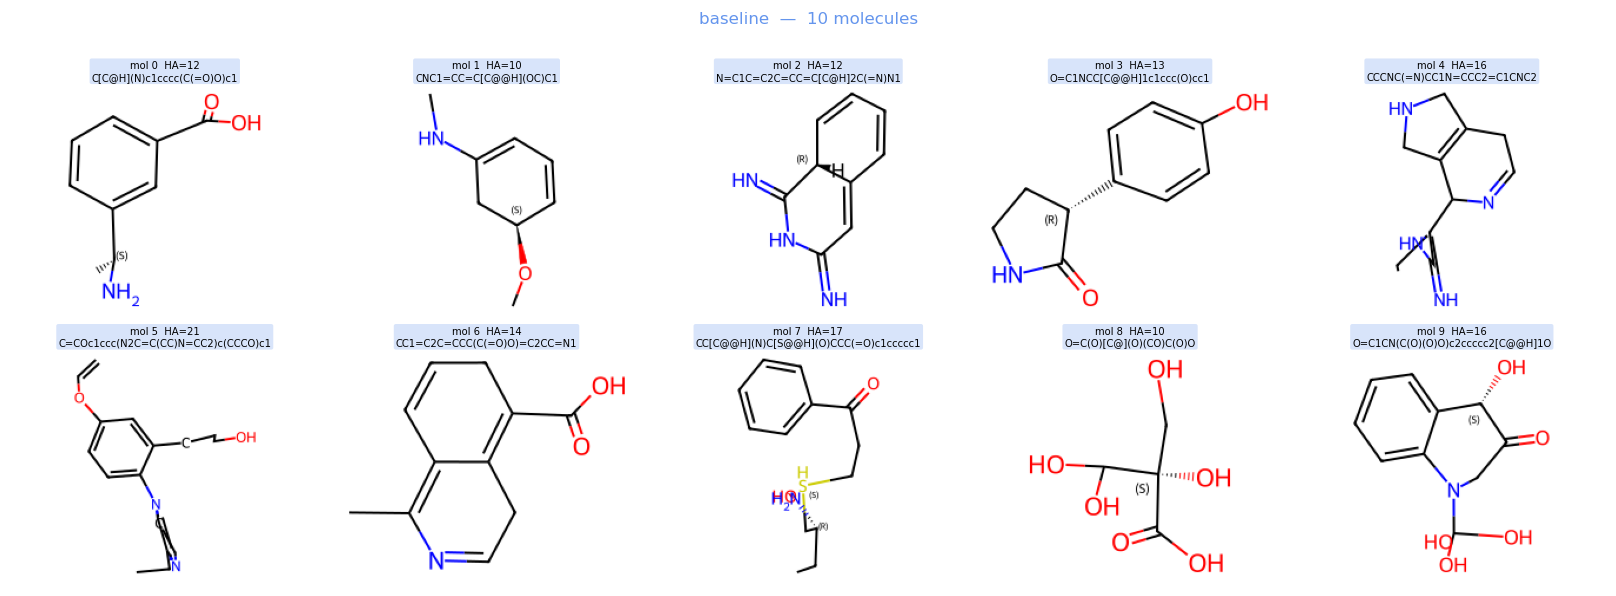

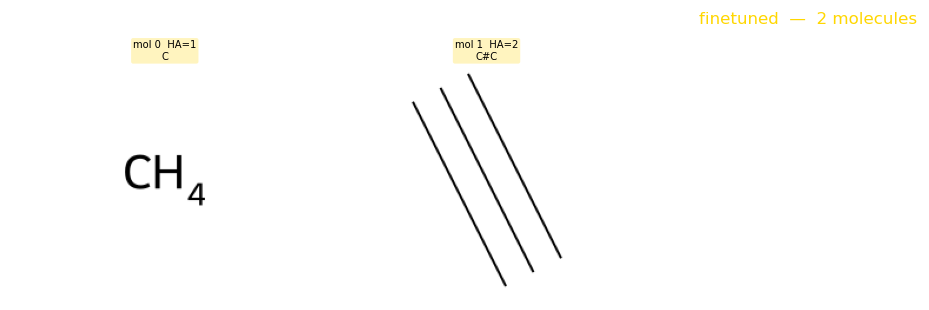

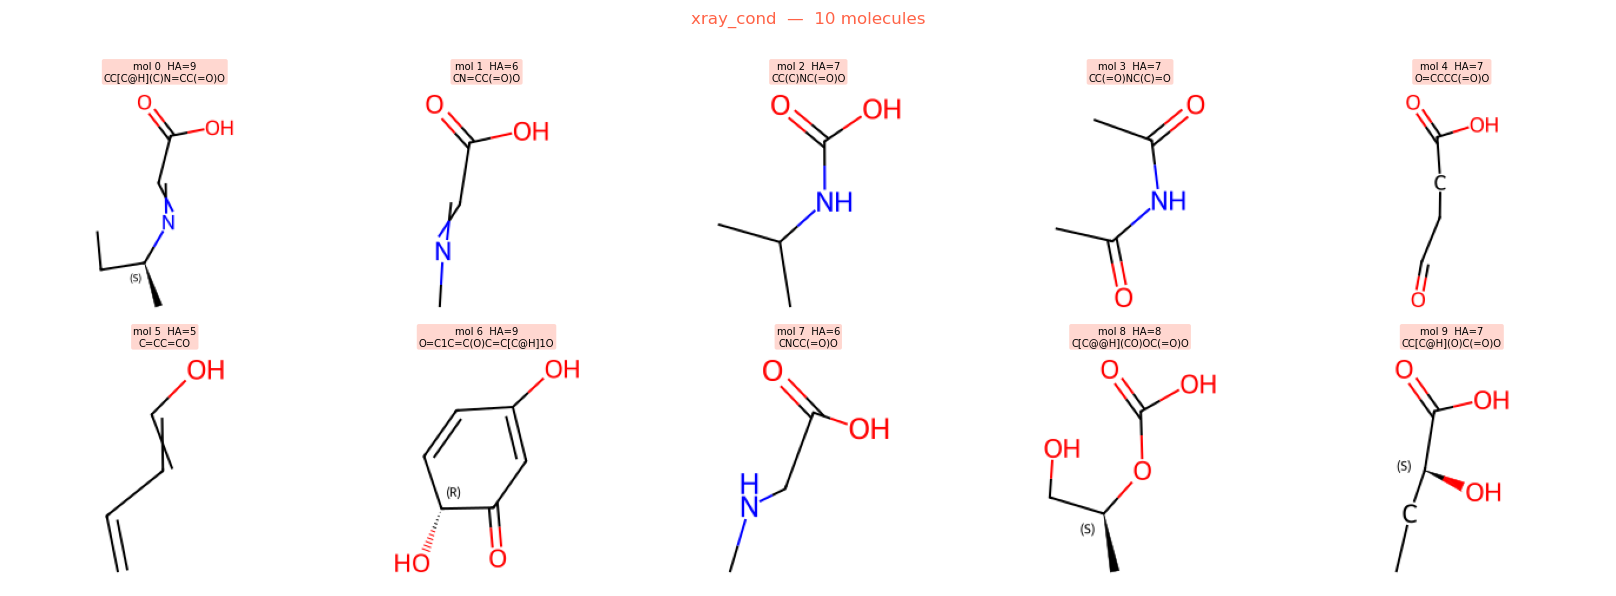

In [56]:
def mol_to_pil(mol, size=(260, 200)):
    drawer = rdMolDraw2D.MolDraw2DCairo(*size)
    drawer.drawOptions().addStereoAnnotation = True
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    return Image.open(BytesIO(drawer.GetDrawingText()))


n_cols = 5
mol_w, mol_h = 260, 200
panel_h = mol_h + 40

for cond, mols in gen_mols.items():
    n_rows = math.ceil(len(mols) / n_cols)
    fig_g, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * mol_w / 96, n_rows * panel_h / 96)
    )
    axes = np.array(axes).reshape(-1)

    for i, mol in enumerate(mols):
        ax = axes[i]
        ax.imshow(mol_to_pil(mol, size=(mol_w, mol_h)))
        ax.axis('off')
        smi = Chem.MolToSmiles(mol)
        ha  = mol.GetNumHeavyAtoms()
        ax.set_title(
            f'mol {i}  HA={ha}\n{smi[:45]}{"…" if len(smi)>45 else ""}',
            fontsize=6, pad=2,
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor=COND_COLOR[cond], alpha=0.25, linewidth=0)
        )

    for j in range(len(mols), len(axes)):
        axes[j].set_visible(False)

    fig_g.suptitle(
        f'{cond}  —  {len(mols)} molecules',
        fontsize=10, y=1.01, color=COND_COLOR[cond]
    )
    fig_g.tight_layout()
    plt.show()

## 6. Per-molecule Metrics

Loaded from `eval_results.pt` (generated by `10_poc_evaluate.sh`).


Summary table:

--------------------------------------------------------------------------------
Metric                              baseline         finetuned         xray_cond
--------------------------------------------------------------------------------
n (molecules)                             10                 2                10
Diversity                              0.904             1.000             0.836
Lipinski mean                          4.900             5.000             5.000
Lipinski median                        5.000             5.000             5.000
LogP mean                              0.940             0.443             0.146
LogP median                            1.155             0.443            -0.011
QED mean                               0.556             0.346             0.483
QED median                             0.568             0.346             0.491
SA mean                                0.706             0.440             0.779
SA median  

/tmp/ipykernel_3059765/3614632926.py:62: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3059765/3614632926.py:62: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3059765/3614632926.py:62: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3059765/3614632926.py:62: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3059765/3614632926.py:62: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



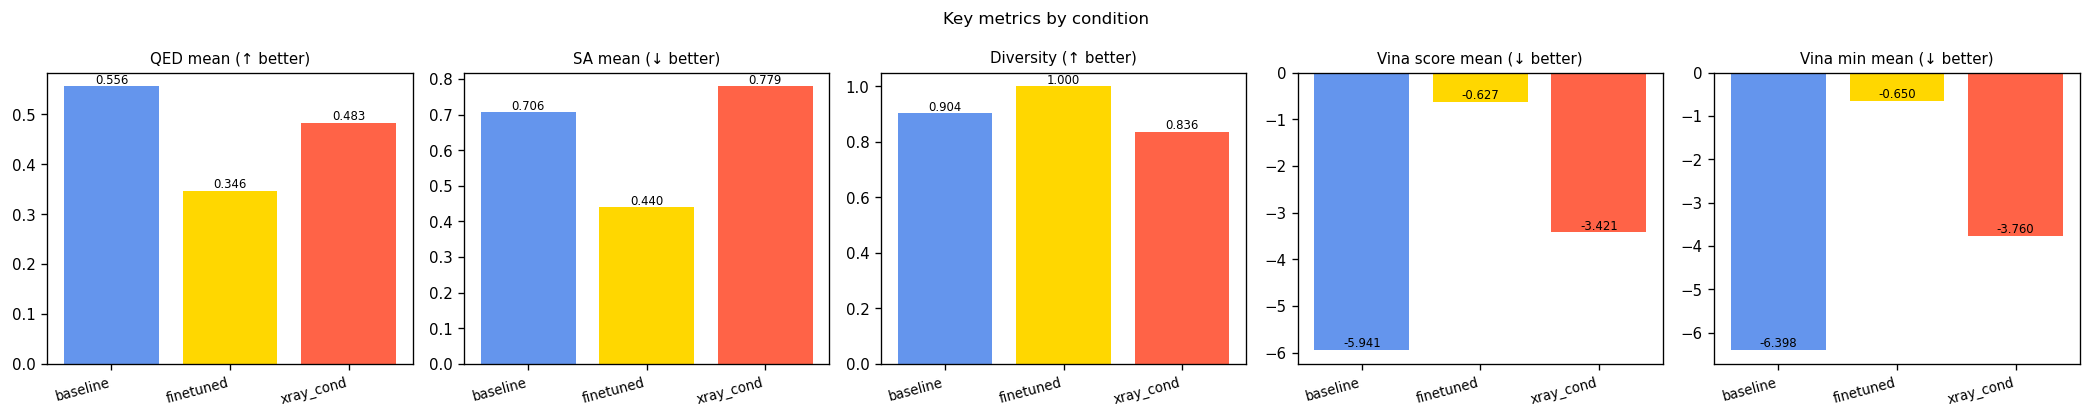

In [66]:
eval_path = COMPARE_DIR / 'eval_results.pt'
if not eval_path.exists():
    print(f'eval_results.pt not found at {eval_path}')
    print('Run: bash scripts/10_poc_evaluate.sh')
else:
    data = torch.load(str(eval_path), weights_only=False)
    summaries = data.get('summaries', {})

    print('\nSummary table:')
    print()
    conditions = list(summaries.keys())
    metrics    = sorted({k for s in summaries.values() for k in s if k != 'n'})

    col_w = 18
    header = f'{"Metric":<26}' + ''.join(f'{c:>{col_w}}' for c in conditions)
    print('-' * len(header))
    print(header)
    print('-' * len(header))
    print(f'{"n (molecules)":<26}' +
          ''.join(f'{summaries[c].get("n", 0):>{col_w}d}' for c in conditions))
    for m in metrics:
        vals = ''.join(
            f'{summaries[c].get(m, float("nan")):>{col_w}.3f}'
            for c in conditions
        )
        print(f'{m:<26}{vals}')
    print('-' * len(header))

    # ── Bar chart of key metrics ───────────────────────────────────────────────
    plot_metrics = ['QED mean', 'SA mean', 'Diversity']

    # Always include Vina metrics if available
    if 'Vina score mean' in metrics:
        plot_metrics.append('Vina score mean')
    if 'Vina min mean' in metrics:
        plot_metrics.append('Vina min mean')

    # Direction of "better" for each metric
    metric_direction = {
        'QED mean': '↑',        # higher is better
        'Diversity': '↑',       # higher is better
        'SA mean': '↓',         # lower (more synthesizable) is better
        'Vina score mean': '↓', # lower (more negative) is better
        'Vina min mean': '↓',   # lower (more negative) is better
    }

    fig_bar, axes = plt.subplots(1, len(plot_metrics),
                                 figsize=(3.5 * len(plot_metrics), 3.5))
    if len(plot_metrics) == 1:
        axes = [axes]

    colors = [COND_COLOR.get(c, 'steelblue') for c in conditions]

    for ax, metric in zip(axes, plot_metrics):
        vals = [summaries[c].get(metric, float('nan')) for c in conditions]
        bars = ax.bar(conditions, vals, color=colors, edgecolor='none')

        arrow = metric_direction.get(metric)
        title = metric if arrow is None else f"{metric} ({arrow} better)"
        ax.set_title(title, fontsize=9)

        ax.set_xticklabels(conditions, rotation=15, ha='right', fontsize=8)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, v,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=7)

    fig_bar.suptitle('Key metrics by condition', fontsize=10)
    fig_bar.tight_layout()
    plt.show()